in this project we will predict passengers who survived the titanic crash. our preditions will be based on certain factors(like age, class etc)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[Hashable, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: '

In [3]:
train_df = pd.read_csv('/kaggle/input/titanic/train.csv',index_col = 'PassengerId' )
test_df = pd.read_csv('/kaggle/input/titanic/test.csv',index_col = 'PassengerId')
sample_file = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')
train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [4]:
test_df


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


In [5]:
sample_file


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [6]:
train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [7]:
train_df.shape,test_df.shape

((891, 11), (418, 10))

In [8]:
train_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [9]:
num_cols = train_df.select_dtypes(include=['int','float'])
cat_cols = train_df.select_dtypes(exclude=['int','float'])
num_cols

,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,,,,,,
1,0,3,22.0,1,0,7.2500
2,1,1,38.0,1,0,71.2833
3,1,3,26.0,0,0,7.9250
4,1,1,35.0,1,0,53.1000
5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
887,0,2,27.0,0,0,13.0000
888,1,1,19.0,0,0,30.0000
889,0,3,NaN,1,2,23.4500


In [10]:
num_cols.shape

(891, 6)

In [11]:
cat_cols

,Name,Sex,Ticket,Cabin,Embarked
PassengerId,,,,,
1,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
3,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
5,"Allen, Mr. William Henry",male,373450,NaN,S
...,...,...,...,...,...
887,"Montvila, Rev. Juozas",male,211536,NaN,S
888,"Graham, Miss. Margaret Edith",female,112053,B42,S
889,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,NaN,S


In [12]:
cat_cols.shape

(891, 5)

In [13]:
num_cols.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

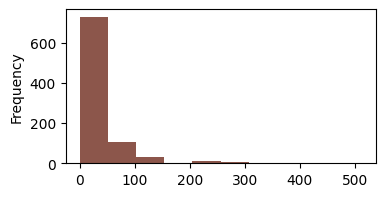

In [14]:
cols =['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
for col in cols:
    num_cols.loc[:,col].plot(kind='hist',figsize=(4,2))
    

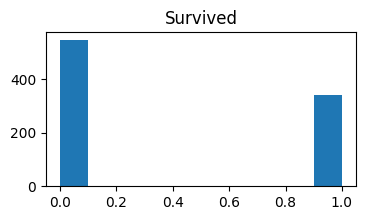

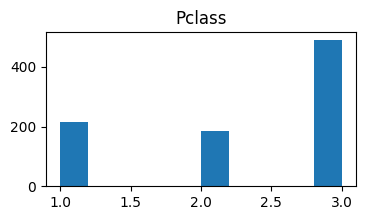

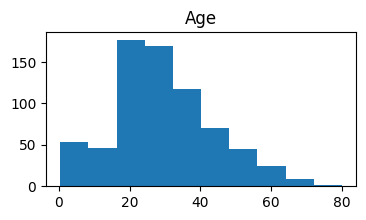

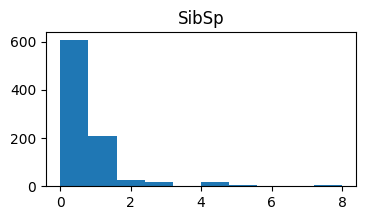

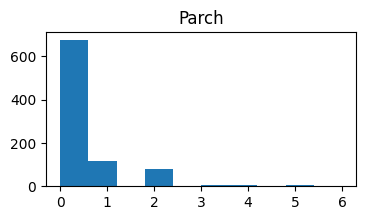

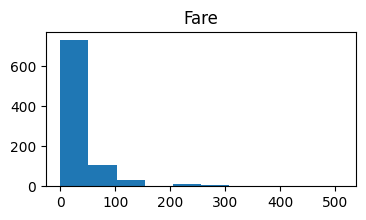

In [15]:
import matplotlib.pyplot as plt
for i in num_cols:
    plt.figure(figsize=(4,2))
    plt.hist(num_cols[i])
    plt.title(f'{i}')
    plt.show()

    

In [16]:
cat_cols.columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [17]:
for col in cat_cols:
    print(cat_cols[col].value_counts())
    print()

    


Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64

Sex
male      577
female    314
Name: count, dtype: int64

Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length:

In [18]:
train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [19]:
def clean_name(df):
     df['Title'] =df['Name'].str.extract(r' ([A-Za-z]+)\.', expand= False)
     df['Name'] = df['Name'].str.replace(r' ([A-Za-z]+)\.', '', regex=True)
     return df

In [20]:
def clean_ticket(df):
    df['ticket_number'] = df['Ticket'].str.extract(r' (\d)', expand = False)
    df['tickId'] = df['Ticket'].str.replace(r' (\d)', '', regex = True)
    df['ticketId'] = df['tickId'].str.replace(r'(\d)','', regex= True)
    df.drop(columns = ['Ticket','ticket_number','tickId' ], inplace=True)
    return df

In [21]:
def clean_cabin(df):
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('U')
    df.drop(columns = 'Cabin', axis=1, inplace=True)
    return df


In [22]:
train_df['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [23]:
train_df['Cabin'].describe()

count     204
unique    147
top        G6
freq        4
Name: Cabin, dtype: object

In [24]:
train_df['Cabin'].notnull().sum()

np.int64(204)

In [25]:
train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [26]:
train_df = clean_name(train_df)
train_df = clean_ticket(train_df)
train_df = clean_cabin(train_df)

In [27]:
test_df = clean_name(test_df)
test_df = clean_ticket(test_df)
test_df = clean_cabin(test_df)

In [28]:
train_df


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,ticketId,Deck
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Owen Harris",male,22.0,1,0,7.2500,S,Mr,A/,U
2,1,1,"Cumings, John Bradley (Florence Briggs Thayer)",female,38.0,1,0,71.2833,C,Mrs,PC,C
3,1,3,"Heikkinen, Laina",female,26.0,0,0,7.9250,S,Miss,STON/O.,U
4,1,1,"Futrelle, Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs,,C
5,0,3,"Allen, William Henry",male,35.0,0,0,8.0500,S,Mr,,U
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Juozas",male,27.0,0,0,13.0000,S,Rev,,U
888,1,1,"Graham, Margaret Edith",female,19.0,0,0,30.0000,S,Miss,,B
889,0,3,"Johnston, Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S,Miss,W./C.,U


In [29]:
test_df

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,ticketId,Deck
PassengerId,,,,,,,,,,,
892,3,"Kelly, James",male,34.5,0,0,7.8292,Q,Mr,,U
893,3,"Wilkes, James (Ellen Needs)",female,47.0,1,0,7.0000,S,Mrs,,U
894,2,"Myles, Thomas Francis",male,62.0,0,0,9.6875,Q,Mr,,U
895,3,"Wirz, Albert",male,27.0,0,0,8.6625,S,Mr,,U
896,3,"Hirvonen, Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,S,Mrs,,U
...,...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Woolf",male,NaN,0,0,8.0500,S,Mr,A..,U
1306,1,"Oliva y Ocana, Fermina",female,39.0,0,0,108.9000,C,Dona,PC,C
1307,3,"Saether, Simon Sivertsen",male,38.5,0,0,7.2500,S,Mr,SOTON/O.Q.,U


In [30]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    object 
 9   Title     891 non-null    object 
 10  ticketId  891 non-null    object 
 11  Deck      891 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 90.5+ KB


# Let's handle missing values. we will fill missing values by grouping or comparing with outhwer groups

In [31]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    object 
 9   Title     891 non-null    object 
 10  ticketId  891 non-null    object 
 11  Deck      891 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 90.5+ KB


lets handle embacked first before age since age may likely depend on embarked

In [32]:
def embarked_cleaned(df):
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    return df

In [33]:
train_df = embarked_cleaned(train_df)
test_df = embarked_cleaned(test_df)

train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,ticketId,Deck
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Owen Harris",male,22.0,1,0,7.2500,S,Mr,A/,U
2,1,1,"Cumings, John Bradley (Florence Briggs Thayer)",female,38.0,1,0,71.2833,C,Mrs,PC,C
3,1,3,"Heikkinen, Laina",female,26.0,0,0,7.9250,S,Miss,STON/O.,U
4,1,1,"Futrelle, Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs,,C
5,0,3,"Allen, William Henry",male,35.0,0,0,8.0500,S,Mr,,U
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Juozas",male,27.0,0,0,13.0000,S,Rev,,U
888,1,1,"Graham, Margaret Edith",female,19.0,0,0,30.0000,S,Miss,,B
889,0,3,"Johnston, Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S,Miss,W./C.,U


In [34]:
train_df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

Lets handle missing age using ML method 

In [35]:
from sklearn.preprocessing import LabelEncoder
def labelencoder(df):
    ticket_label = LabelEncoder()
    deck_label = LabelEncoder()
    title_label = LabelEncoder()
    df['Deck'] = deck_label.fit_transform(df['Deck'])
    df['ticketId'] = ticket_label.fit_transform(df['ticketId'])
    df['Title'] = title_label.fit_transform(df['Title'])
    return df

In [36]:
def ml_model(df):
    feat = df[['Pclass','Embarked','Title','Sex','SibSp','Parch','Fare', 'Age']].copy()
    feat['Sex'] = feat['Sex'].map({
    'male':0,
    'female':1
})
    feat['Embarked'] = feat['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

    from sklearn.preprocessing import LabelEncoder
    return feat

In [37]:
train_df = labelencoder(train_df)
test_df = labelencoder(test_df)
test_df

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,ticketId,Deck
PassengerId,,,,,,,,,,,
892,3,"Kelly, James",male,34.5,0,0,7.8292,Q,5,0,7
893,3,"Wilkes, James (Ellen Needs)",female,47.0,1,0,7.0000,S,6,0,7
894,2,"Myles, Thomas Francis",male,62.0,0,0,9.6875,Q,5,0,7
895,3,"Wirz, Albert",male,27.0,0,0,8.6625,S,5,0,7
896,3,"Hirvonen, Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,S,6,0,7
...,...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Woolf",male,NaN,0,0,8.0500,S,5,1,7
1306,1,"Oliva y Ocana, Fermina",female,39.0,0,0,108.9000,C,1,14,2
1307,3,"Saether, Simon Sivertsen",male,38.5,0,0,7.2500,S,5,26,7


In [38]:
featt = ml_model(train_df)
featt2 =ml_model(test_df)

In [39]:
featt

,Pclass,Embarked,Title,Sex,SibSp,Parch,Fare,Age
PassengerId,,,,,,,,
1,3,0,12,0,1,0,7.2500,22.0
2,1,1,13,1,1,0,71.2833,38.0
3,3,0,9,1,0,0,7.9250,26.0
4,1,0,13,1,1,0,53.1000,35.0
5,3,0,12,0,0,0,8.0500,35.0
...,...,...,...,...,...,...,...,...
887,2,0,15,0,0,0,13.0000,27.0
888,1,0,9,1,0,0,30.0000,19.0
889,3,0,9,1,1,2,23.4500,NaN


In [40]:
featt2

,Pclass,Embarked,Title,Sex,SibSp,Parch,Fare,Age
PassengerId,,,,,,,,
892,3,2,5,0,0,0,7.8292,34.5
893,3,0,6,1,1,0,7.0000,47.0
894,2,2,5,0,0,0,9.6875,62.0
895,3,0,5,0,0,0,8.6625,27.0
896,3,0,6,1,1,1,12.2875,22.0
...,...,...,...,...,...,...,...,...
1305,3,0,5,0,0,0,8.0500,NaN
1306,1,1,1,1,0,0,108.9000,39.0
1307,3,0,5,0,0,0,7.2500,38.5


In [41]:
def ml_model(df):
    # Split known and missing Age
    known = df[df['Age'].notnull()]
    missing = df[df['Age'].isnull()]
    
    # Prepare training data
    X_train = df.loc[known.index]
    y_train = known['Age']
    
    X_test = df.loc[missing.index]
    
    # Train model
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor()
    model.fit(X_train, y_train)
    
    # Predict missing Age
    predicted = model.predict(X_test)
    
    # Fill missing Age
    df.loc[df['Age'].isnull(), 'Age'] = predicted
    
    return df

In [42]:
train_df_new = ml_model(featt)
test_df_new = ml_model(featt2)

In [43]:
train_df_new

,Pclass,Embarked,Title,Sex,SibSp,Parch,Fare,Age
PassengerId,,,,,,,,
1,3,0,12,0,1,0,7.2500,22.00
2,1,1,13,1,1,0,71.2833,38.00
3,3,0,9,1,0,0,7.9250,26.00
4,1,0,13,1,1,0,53.1000,35.00
5,3,0,12,0,0,0,8.0500,35.00
...,...,...,...,...,...,...,...,...
887,2,0,15,0,0,0,13.0000,27.00
888,1,0,9,1,0,0,30.0000,19.00
889,3,0,9,1,1,2,23.4500,25.41


In [44]:
test_df_new

,Pclass,Embarked,Title,Sex,SibSp,Parch,Fare,Age
PassengerId,,,,,,,,
892,3,2,5,0,0,0,7.8292,34.50
893,3,0,6,1,1,0,7.0000,47.00
894,2,2,5,0,0,0,9.6875,62.00
895,3,0,5,0,0,0,8.6625,27.00
896,3,0,6,1,1,1,12.2875,22.00
...,...,...,...,...,...,...,...,...
1305,3,0,5,0,0,0,8.0500,23.21
1306,1,1,1,1,0,0,108.9000,39.00
1307,3,0,5,0,0,0,7.2500,38.50


In [45]:
train_df_new['Title'].isnull().sum()

np.int64(0)

In [46]:
def merged(df1,df2):
    df1[['Embarked','Title','Age','Sex']] =df2[['Embarked','Title','Age','Sex']]
    return df1
    

In [47]:
train_df = merged(train_df,train_df_new)
test_df = merged(test_df,test_df_new)


In [48]:
train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,ticketId,Deck
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Owen Harris",0,22.00,1,0,7.2500,0,12,4,8
2,1,1,"Cumings, John Bradley (Florence Briggs Thayer)",1,38.00,1,0,71.2833,1,13,17,2
3,1,3,"Heikkinen, Laina",1,26.00,0,0,7.9250,0,9,36,8
4,1,1,"Futrelle, Jacques Heath (Lily May Peel)",1,35.00,1,0,53.1000,0,13,0,2
5,0,3,"Allen, William Henry",0,35.00,0,0,8.0500,0,12,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Juozas",0,27.00,0,0,13.0000,0,15,0,8
888,1,1,"Graham, Margaret Edith",1,19.00,0,0,30.0000,0,9,0,1
889,0,3,"Johnston, Catherine Helen ""Carrie""",1,25.41,1,2,23.4500,0,9,38,8


In [49]:
test_df

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,ticketId,Deck
PassengerId,,,,,,,,,,,
892,3,"Kelly, James",0,34.50,0,0,7.8292,2,5,0,7
893,3,"Wilkes, James (Ellen Needs)",1,47.00,1,0,7.0000,0,6,0,7
894,2,"Myles, Thomas Francis",0,62.00,0,0,9.6875,2,5,0,7
895,3,"Wirz, Albert",0,27.00,0,0,8.6625,0,5,0,7
896,3,"Hirvonen, Alexander (Helga E Lindqvist)",1,22.00,1,1,12.2875,0,6,0,7
...,...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Woolf",0,23.21,0,0,8.0500,0,5,1,7
1306,1,"Oliva y Ocana, Fermina",1,39.00,0,0,108.9000,1,1,14,2
1307,3,"Saether, Simon Sivertsen",0,38.50,0,0,7.2500,0,5,26,7


In [50]:
train_df['Deck'].value_counts()

Deck
8    687
2     59
1     47
3     33
4     32
0     15
5     13
6      4
7      1
Name: count, dtype: int64

In [51]:
train_df = labelencoder(train_df)
test_df = labelencoder(test_df)


In [52]:
train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,ticketId,Deck
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Owen Harris",0,22.00,1,0,7.2500,0,12,4,8
2,1,1,"Cumings, John Bradley (Florence Briggs Thayer)",1,38.00,1,0,71.2833,1,13,17,2
3,1,3,"Heikkinen, Laina",1,26.00,0,0,7.9250,0,9,36,8
4,1,1,"Futrelle, Jacques Heath (Lily May Peel)",1,35.00,1,0,53.1000,0,13,0,2
5,0,3,"Allen, William Henry",0,35.00,0,0,8.0500,0,12,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Juozas",0,27.00,0,0,13.0000,0,15,0,8
888,1,1,"Graham, Margaret Edith",1,19.00,0,0,30.0000,0,9,0,1
889,0,3,"Johnston, Catherine Helen ""Carrie""",1,25.41,1,2,23.4500,0,9,38,8


In [53]:
test_df

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,ticketId,Deck
PassengerId,,,,,,,,,,,
892,3,"Kelly, James",0,34.50,0,0,7.8292,2,5,0,7
893,3,"Wilkes, James (Ellen Needs)",1,47.00,1,0,7.0000,0,6,0,7
894,2,"Myles, Thomas Francis",0,62.00,0,0,9.6875,2,5,0,7
895,3,"Wirz, Albert",0,27.00,0,0,8.6625,0,5,0,7
896,3,"Hirvonen, Alexander (Helga E Lindqvist)",1,22.00,1,1,12.2875,0,6,0,7
...,...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Woolf",0,23.21,0,0,8.0500,0,5,1,7
1306,1,"Oliva y Ocana, Fermina",1,39.00,0,0,108.9000,1,1,14,2
1307,3,"Saether, Simon Sivertsen",0,38.50,0,0,7.2500,0,5,26,7


In [54]:
def dropp(df):
    df = df.drop(columns = 'Name')
    return df
    

In [55]:
train_df = dropp(train_df)

In [56]:
test_df = dropp(test_df)

In [57]:
train_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
ticketId    0
Deck        0
dtype: int64

In [58]:
test_df.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        1
Embarked    0
Title       0
ticketId    0
Deck        0
dtype: int64

<Axes: >

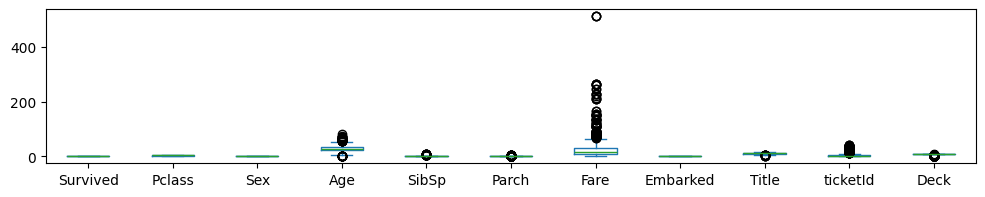

In [59]:
train_df.plot(kind = 'box',figsize = (12,2))

In [60]:
def cap_outliers(data,ft):
    q1 = data[ft].quantile(0.25)
    q3 = data[ft].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - (1.5*iqr)
    ub = q3 + (1.5*iqr)
    data[ft] = data[ft].clip(lower= lb, upper= ub)
    return data

In [61]:
for col in train_df.columns:
    train_df = cap_outliers(train_df,col)
    

In [62]:
for col in test_df.columns:
    test_df = cap_outliers(test_df,col)

<Axes: >

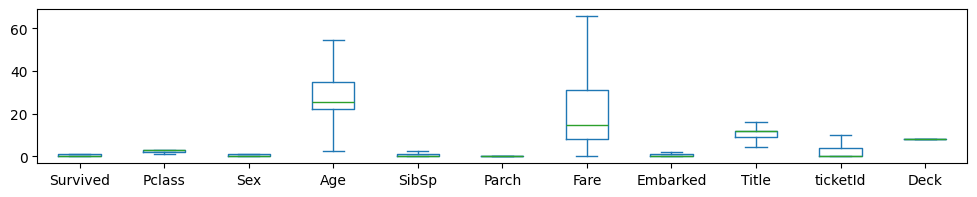

In [63]:
train_df.plot(kind = 'box',figsize = (12,2))

<Axes: >

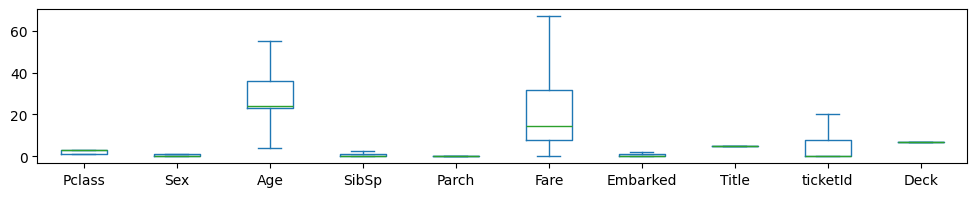

In [64]:
test_df.plot(kind = 'box',figsize = (12,2))

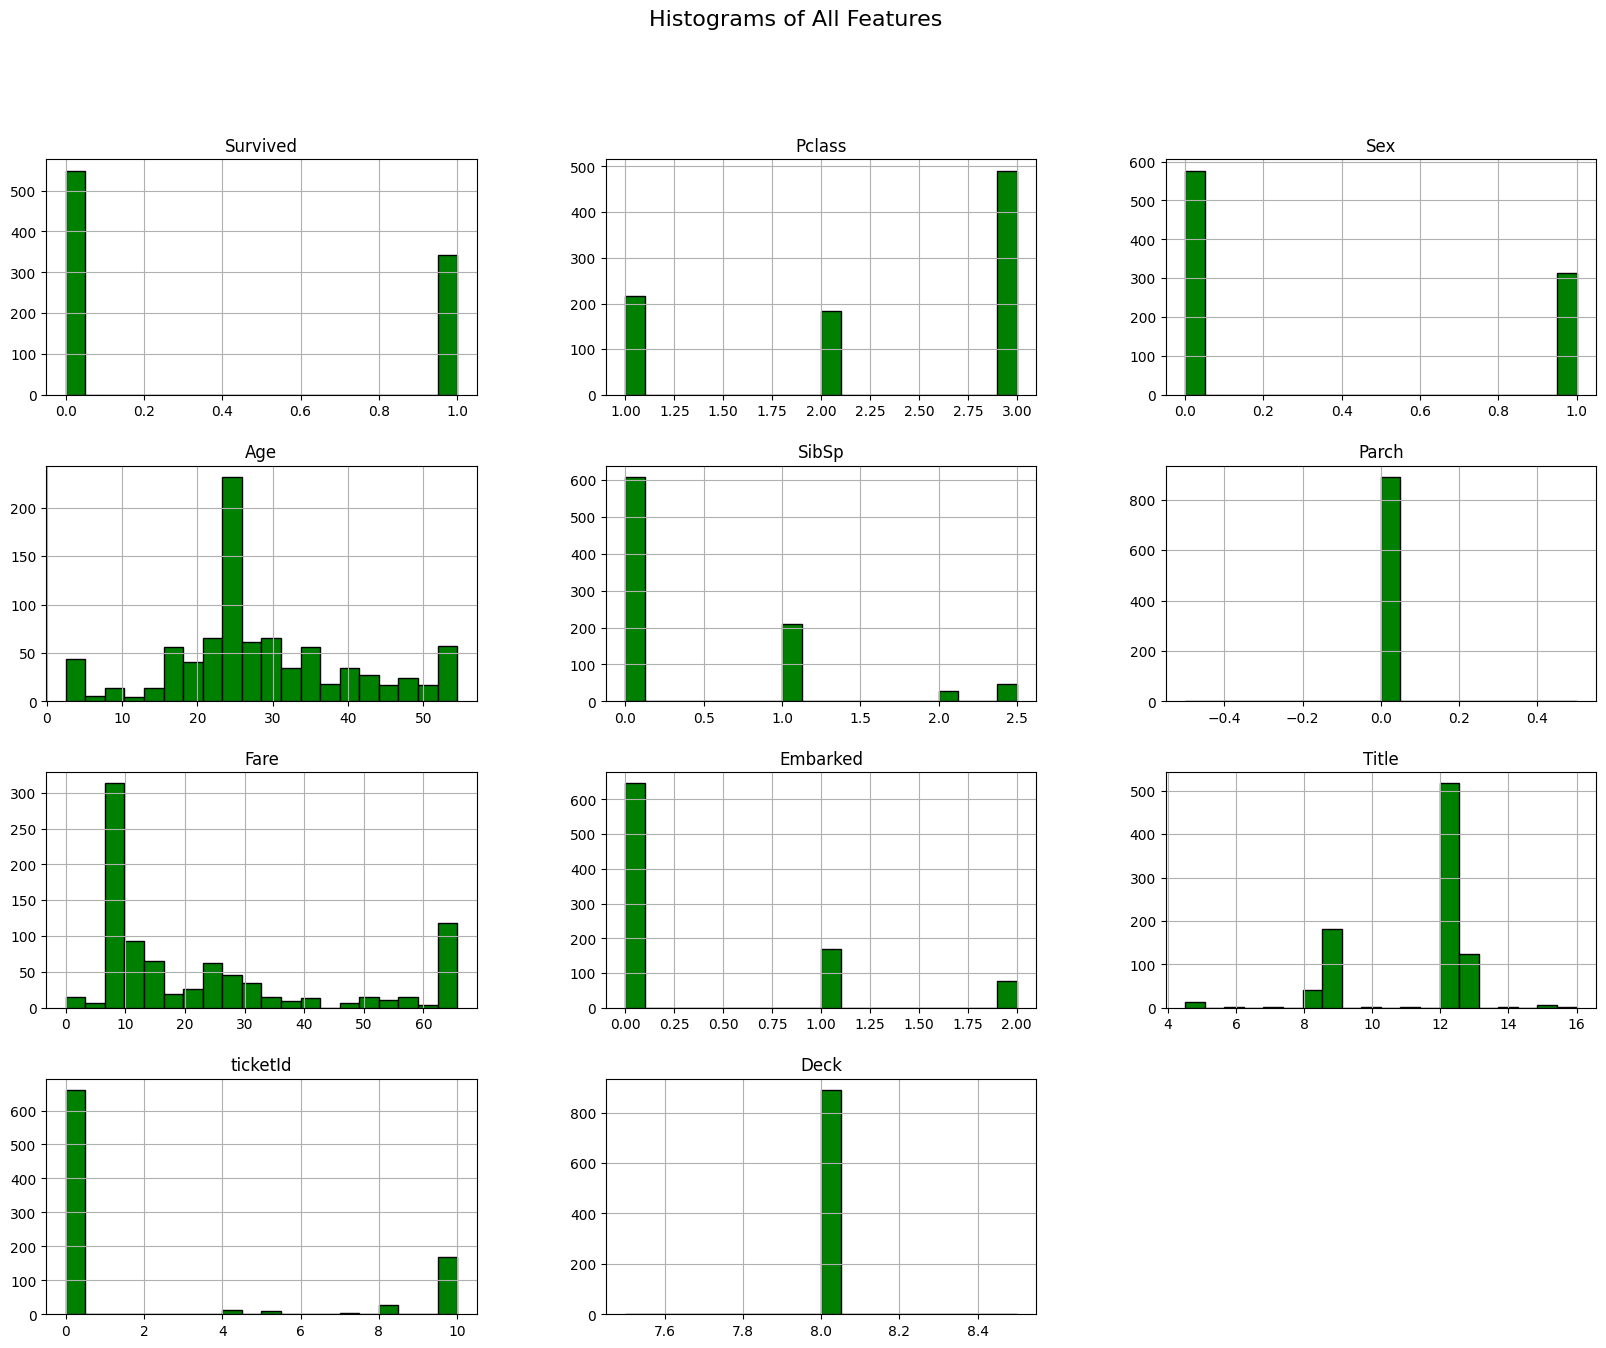

In [65]:
# Plotting histograms for all features
train_df.hist(bins=20, figsize=(20, 15), color='green', edgecolor='black')
plt.suptitle('Histograms of All Features', fontsize=16)
plt.show()

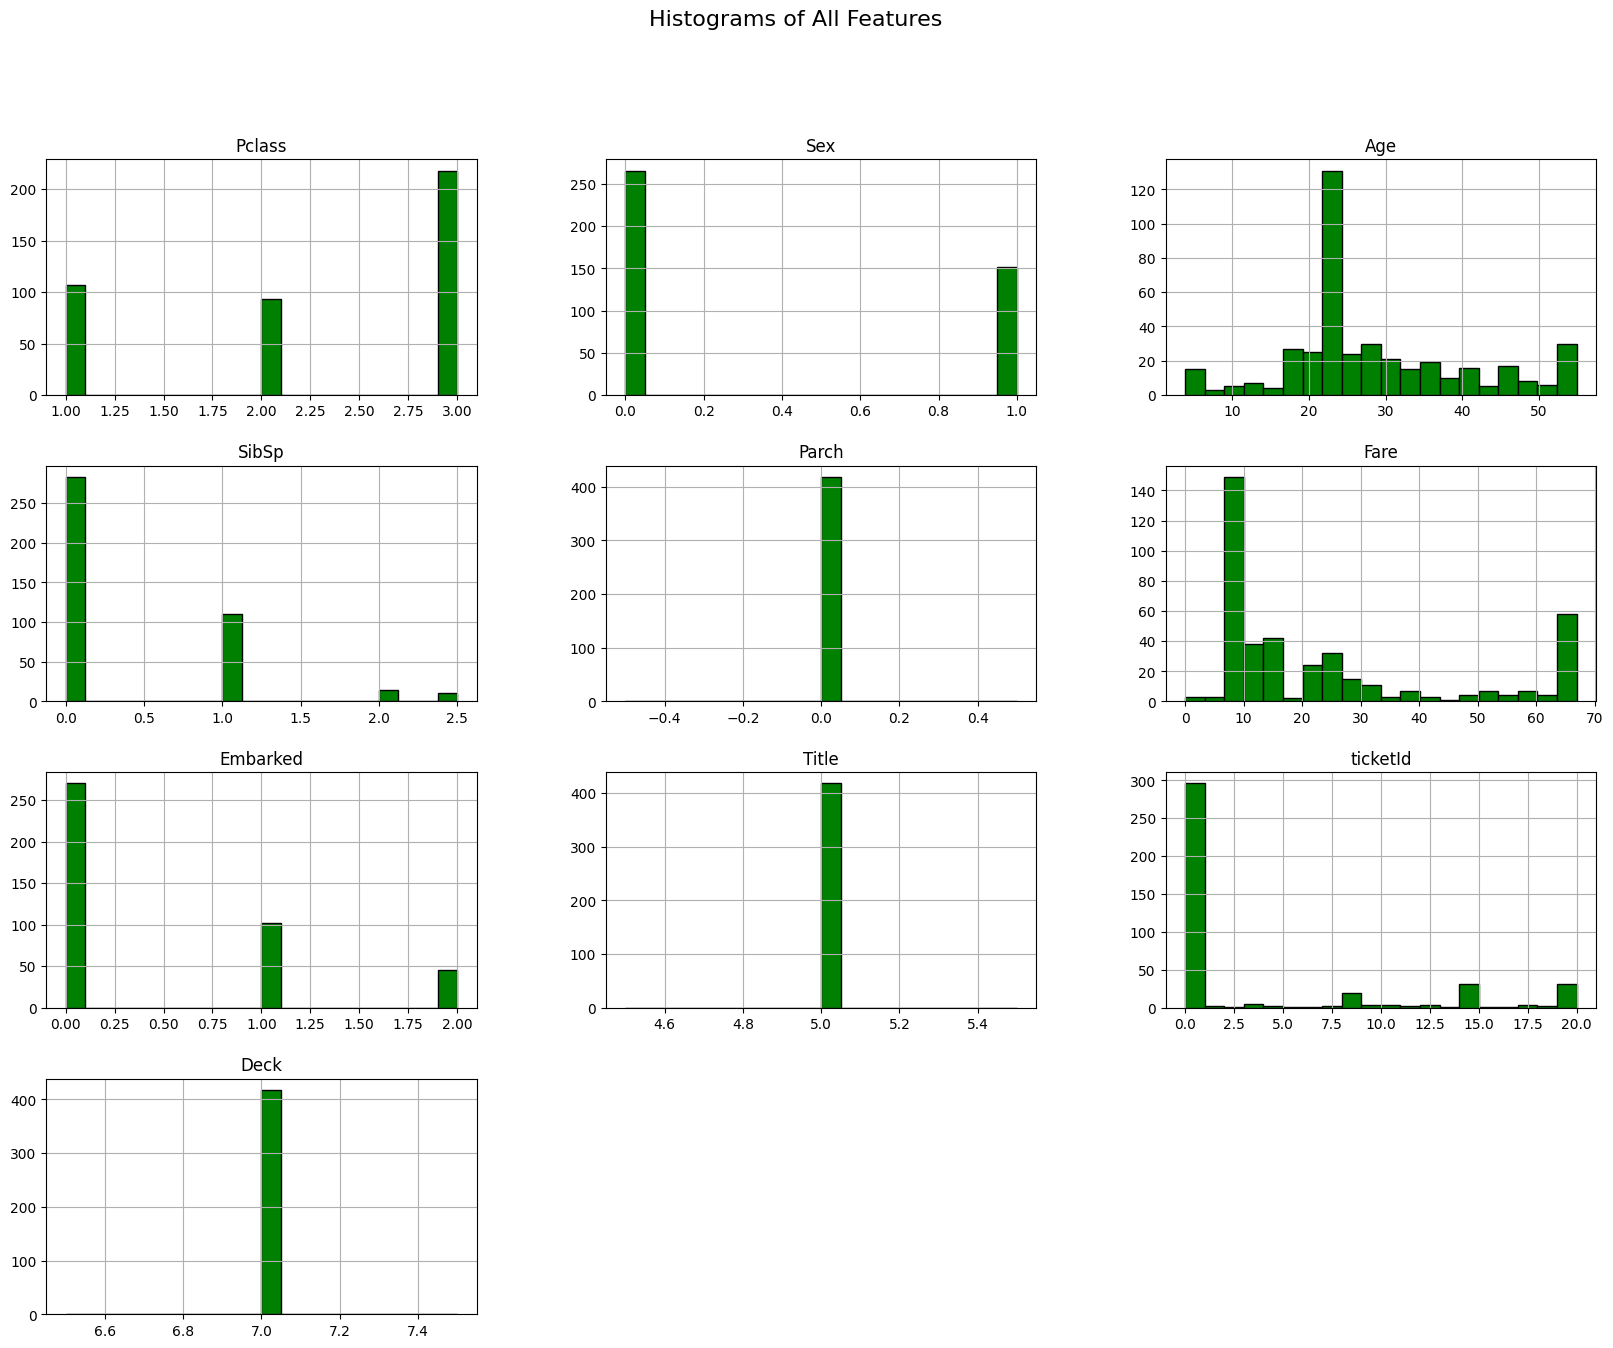

In [66]:
test_df.hist(bins=20, figsize=(20, 15), color='green', edgecolor='black')
plt.suptitle('Histograms of All Features', fontsize=16)
plt.show()

# Now let's define the targets and the features so we can start modeling



In [67]:
X = train_df.drop(columns = 'Survived')
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,ticketId,Deck
PassengerId,,,,,,,,,,
1,3,0,22.00,1.0,0,7.2500,0,12.0,4,8
2,1,1,38.00,1.0,0,65.6344,1,13.0,10,8
3,3,1,26.00,0.0,0,7.9250,0,9.0,10,8
4,1,1,35.00,1.0,0,53.1000,0,13.0,0,8
5,3,0,35.00,0.0,0,8.0500,0,12.0,0,8
...,...,...,...,...,...,...,...,...,...,...
887,2,0,27.00,0.0,0,13.0000,0,15.0,0,8
888,1,1,19.00,0.0,0,30.0000,0,9.0,0,8
889,3,1,25.41,1.0,0,23.4500,0,9.0,10,8


In [68]:
y = train_df['Survived']
y

PassengerId
1      0
2      1
3      1
4      1
5      0
      ..
887    0
888    1
889    0
890    1
891    0
Name: Survived, Length: 891, dtype: int64

In [69]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1,random_state = 1212 )

In [70]:
from sklearn.linear_model import LogisticRegression
import joblib
from sklearn.metrics import accuracy_score

clf = LogisticRegression(random_state = 0,max_iter = 500).fit(X_train, y_train)
prediction = clf.predict(X_test)
accuracy = accuracy_score(y_test,prediction)

In [71]:
accuracy

0.7444444444444445

In [72]:
test_df.isnull().sum()
test_df['Fare'] = test_df['Age'].fillna(test_df['Fare'].mean())

In [73]:
# Generate predictions using your trained model
titanic_predictions_n = clf.predict(test_df)

In [74]:
test_df.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title',
       'ticketId', 'Deck'],
      dtype='object')

In [75]:
titanic_predictions_n

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,

In [76]:
submission = pd.DataFrame({
    'PassengerId': test_df.index,
    'Survived': titanic_predictions_n
})   #note that test_dfindex and predicted values will be used

In [77]:
submission.to_csv('submission_new.csv', index=False)

**I will try out other models from gradient boosting to tree based to clasification models**

In [78]:
from sklearn.ensemble import GradientBoostingClassifier
GradientBoostingClassifier = GradientBoostingClassifier(
    learning_rate=0.01,
    max_depth=10,
    max_features=0.8,
    min_samples_leaf=2,
    min_samples_split=2,
    n_estimators=100,
    subsample=0.4,
    random_state=42
)
GradientBoostingClassifier.fit(X_train, y_train)
acc_GBC = round(GradientBoostingClassifier.score(X_train, y_train) * 100, 3)
GBC = round(GradientBoostingClassifier.score(X_test, y_test) * 100, 3)
print("Train: ", acc_GBC)
print("Test: ", GBC)

Train:  90.637
Test:  84.444


In [79]:
rough_prediction =GradientBoostingClassifier.predict(X_test)
accuracy = accuracy_score(rough_prediction,y_test)
accuracy

0.8444444444444444

In [80]:
predictions =GradientBoostingClassifier.predict(test_df)

In [81]:
submission = pd.DataFrame({
    'PassengerId': test_df.index,
    'Survived': predictions
})

In [82]:
submission.to_csv('submission_filee.csv' ,index = False)

In [83]:
from sklearn.ensemble import ExtraTreesClassifier
ExtraTreesClassifier = ExtraTreesClassifier(
    bootstrap=True,
    criterion='gini',
    max_features=0.65,
    min_samples_leaf=1,
    min_samples_split=6,
    n_estimators=100,
    random_state=42
)
ExtraTreesClassifier.fit(X_train, y_train)
acc_extra_tree = round(ExtraTreesClassifier.score(X_train, y_train) * 100, 3)
extra_tree = round(ExtraTreesClassifier.score(X_test, y_test) * 100, 3)
print("Train: ", acc_extra_tree)
print("Test: ", extra_tree)

Train:  90.886
Test:  81.111


In [84]:
predictin = ExtraTreesClassifier.predict(test_df)

In [85]:
submission = pd.DataFrame({
    'PassengerId': test_df.index,
    'Survived': predictin
})

In [86]:
submission.to_csv('predictionss.csv', index = False)